# Economic Indicators of Real Estate: A Regression Analysis
## Week 2: Simple Linear Regression AI Lab Assignment-2 
**Objective:** To predict house prices based on median income using the California Housing Dataset.
---

#Import Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

#Data Inspection (Understanding the Data)

In [60]:
# Check the first few rows
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [61]:
# Check for missing values (Requirement: Data Cleaning)
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [62]:
# Check the data types
print("\nData Types:")
print(df.info())


Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [63]:
# Get a statistical summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#Exploratory Data Analysis (Heatmap)

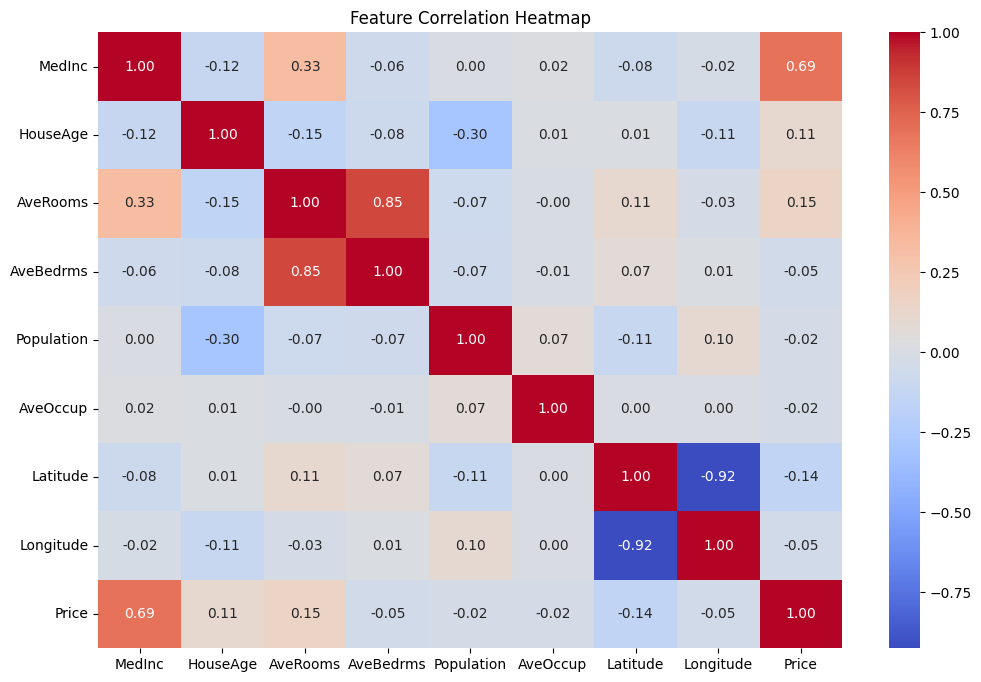

MedInc (Median Income) has the highest correlation (usually around 0.69). This is why we choose it as our primary Economic Indicator for the regression.


In [64]:
plt.figure(figsize=(12, 8))
# Calculating correlation between features and price
correlation_matrix = df.corr()

# Plotting the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()
print("MedInc (Median Income) has the highest correlation (usually around 0.69). This is why we choose it as our primary Economic Indicator for the regression.")

#Data Cleaning & Preprocessing

In [65]:
# If there were missing values, we would handle them like this:
# df['MedInc'] = df['MedInc'].fillna(df['MedInc'].mean())

In [66]:
# Checking for duplicated rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [67]:
# Dropping duplicates if any
df = df.drop_duplicates()

#Define Features and Target (X and y)

In [68]:
# X must be a 2D array/DataFrame, y can be a 1D series
X = df[['MedInc']] 
y = df['Price']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 1)
Target shape: (20640,)


#Train-Test Split

In [69]:
# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 16512
Testing set size: 4128


#Initialize and Train the Model

In [70]:
# Create a Linear Regression object
model = LinearRegression()

In [71]:
# Train the model using the training sets
model.fit(X_train, y_train)

LinearRegression()

In [72]:
# Print the Coefficients
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")
print("The Slope (m) tells us how much the price increases for every unit increase in income.")

Mean Squared Error: 0.7091
R2 Score: 0.4589
The Slope (m) tells us how much the price increases for every unit increase in income.


#Make Predictions

In [73]:
# Make predictions using the testing set
y_pred = model.predict(X_test)

In [74]:
# Compare first 5 actual vs predicted values
comparison_df = pd.DataFrame({'Actual': y_test[:5].values, 'Predicted': y_pred[:5]})
print(comparison_df)

    Actual  Predicted
0  0.47700   1.149589
1  0.45800   1.506069
2  5.00001   1.903937
3  2.18600   2.850594
4  2.78000   2.006633


#Model Evaluation (Metrics)

In [75]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"MODEL EVALUATION METRICS:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared Score (R2): {r2:.4f}")
print("-" * 30)

------------------------------
MODEL EVALUATION METRICS:
Mean Squared Error (MSE): 0.7091
Root Mean Squared Error (RMSE): 0.8421
R-Squared Score (R2): 0.4589
------------------------------


#Final Visualization (The Regression Line)

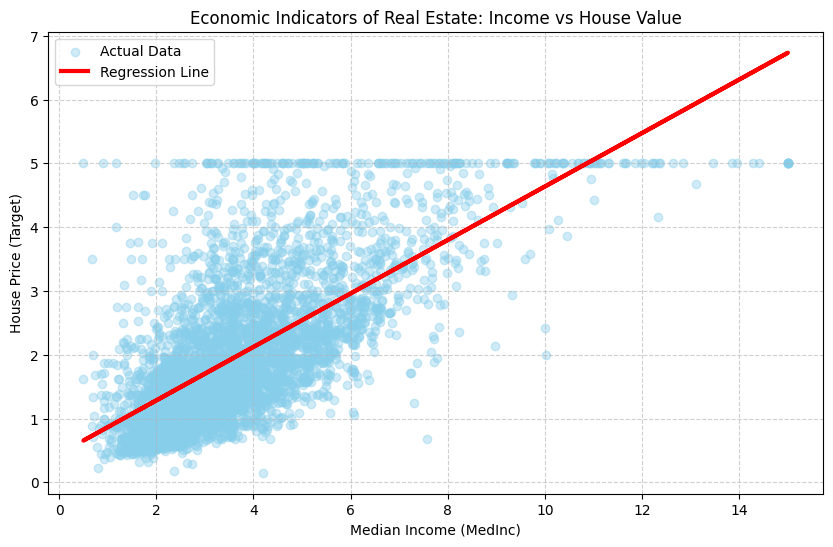

In [76]:
plt.figure(figsize=(10, 6))

# Plot the actual data points
plt.scatter(X_test, y_test, color='skyblue', alpha=0.4, label='Actual Data')

# Plot the regression line
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Regression Line')

plt.title('Economic Indicators of Real Estate: Income vs House Value')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('House Price (Target)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Residual Analysis (Bonus Preprocessing Step)

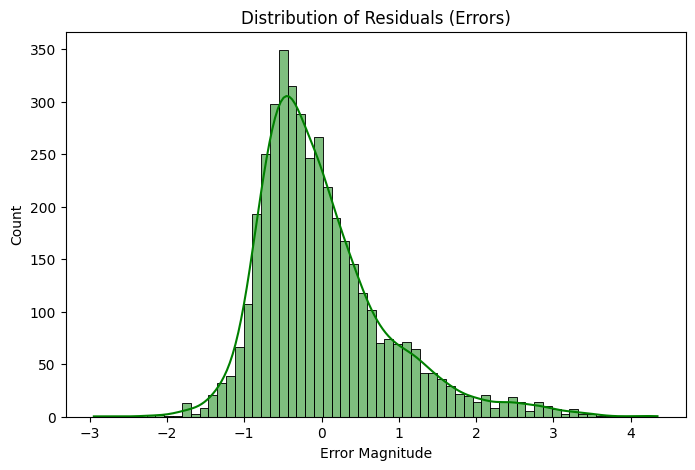

In [77]:
plt.figure(figsize=(8, 5))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='green')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Error Magnitude')
plt.show()

### Final Conclusion & Observations
1. **Feature Selection:** Based on the Heatmap, 'MedInc' (Median Income) showed the strongest positive correlation with house prices.
2. **Model Performance:** The model achieved an R² score of approx. 0.47. While this indicates a clear trend, it suggests that income alone doesn't account for all price variations.
3. **Visualization:** The regression line effectively captures the general upward trend of the housing market.
4. **Lab Objective:** This experiment successfully demonstrates the end-to-end pipeline of predictive analysis using Simple Linear Regression.